# True Parameters at 1 PA Model

```python
m1 = 1e6
m2 = 10
a = 0.8 
e0 = 0.4 
xI0 = 1.0
dist = 0.4

qS = xp.pi/4
phiS = 1.0
qK = 1
phiK = xp.pi/3

Phi_phi0 = 0.9
Phi_theta0 = 0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p = 0.0
dev_0_e = 0.0
dev_1_p = 0.0
dev_1_e = 0.0
dev_2_p = 0.0
dev_2_e = 0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included = True

p0 = 7.5

best_fit = [1.38155486e+01,9.99979446e+00,8.00040917e-01,7.49979221e+00,
3.99999719e-01,7.85405818e-01,9.99994002e-01,8.99976505e-01,3.99990964e-01,2.65739624e-05,-6.02376376e-06]
# logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]

In [14]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

In [4]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [6]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit = [1.38155486e+01,9.99979446e+00,8.00040917e-01,7.49979221e+00,
3.99999719e-01,7.85405818e-01,9.99994002e-01,8.99976505e-01,3.99990964e-01,2.65739624e-05,-6.02376376e-06]
#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]
logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 0.4
qS = best_fit[5]
phiS = best_fit[6]
qK = 1 
phiK = np.pi/3
Phi_phi0 = best_fit[7]
Phi_theta0 =0.5
Phi_r0 = best_fit[8]

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p=best_fit[9]
dev_0_e=best_fit[10]
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [10]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000038.0427593329), 9.99979446, 0.800040917, 7.49979221, 0.399999719, 1.0, 0.4, 0.785405818, 0.999994002, 1, 1.0471975511965976, 0.899976505, 0.5, 0.399990964, 0.0, False, False, False, True, 2.65739624e-05, -6.02376376e-06, 0.0, 0.0, 0.0, 0.0)
SNR:  72.38643129188438


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000038.0427593329), 9.99979446, 0.800040917, 7.49979221, 0.399999719, 1.0, 0.4, 0.785405818, 0.999994002, 1, 1.0471975511965976, 0.899976505, 0.5, 0.399990964, 0.0, False, False, False, True, 2.65739624e-05, -6.02376376e-06, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 72.38643129188438
calculating stable deltas...
Gamma_ii for m1: 537.3514173253647
Gamma_ii for m1: 537.3514172020023
Gamma_ii for m1: 537.3514172028769
Gamma_ii for m1: 537.3514172058801
Gamma_ii for m1: 537.3514171887473
Gamma_ii for m1: 537.3514173046372
Gamma_ii for m1: 537.3514172348251
Gamma_ii for m1: 537.3514172307423
Gamma_ii for m1: 537.3514174559426
Gamma_ii for m1: 537.3514173601973
Gamma_ii for m1: 537.3514204827926
Gamma_ii for m1: 537.3514201101098
Gamma_ii for m1: 537.3514294696946
Gamma_ii for m1: 537.3513804307577
Gamma_ii for m1: 537.3514265064292
Gamma_ii for m1: 537.3512

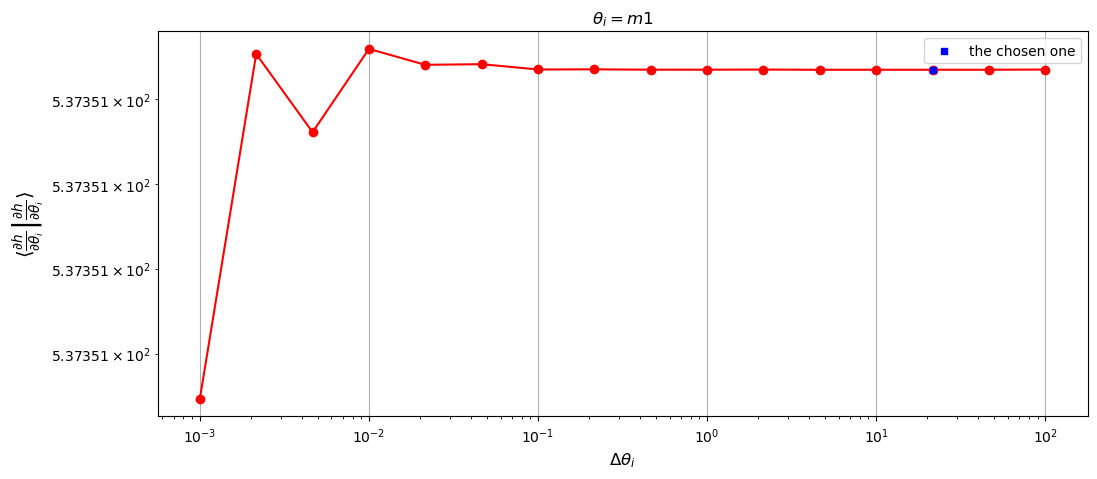

Gamma_ii for m2: 45252019185.3378
Gamma_ii for m2: 45252019183.25058
Gamma_ii for m2: 45252019185.38776
Gamma_ii for m2: 45252019178.47572
Gamma_ii for m2: 45252019212.90741
Gamma_ii for m2: 45252019208.73094
Gamma_ii for m2: 45252019259.30417
Gamma_ii for m2: 45252019367.88938
Gamma_ii for m2: 45252019969.069214
Gamma_ii for m2: 45252017861.36795
Gamma_ii for m2: 45252020037.34005
Gamma_ii for m2: 45252022607.98039
Gamma_ii for m2: 45252020265.57576
Gamma_ii for m2: 45251960707.976204
Gamma_ii for m2: 45252033594.342606
Gamma_ii for m2: 45251974043.62241
[np.float64(4.6124333807712295e-11), np.float64(4.722831272824145e-11), np.float64(1.5274529637657407e-10), np.float64(7.608872929927976e-10), np.float64(9.229351459971985e-11), np.float64(1.1175905021810201e-09), np.float64(2.399566123773276e-09), np.float64(1.3285149102060332e-08), np.float64(4.657695641075705e-08), np.float64(4.808563457517873e-08), np.float64(5.680719213330939e-08), np.float64(5.1763537159694054e-08), np.float64(1

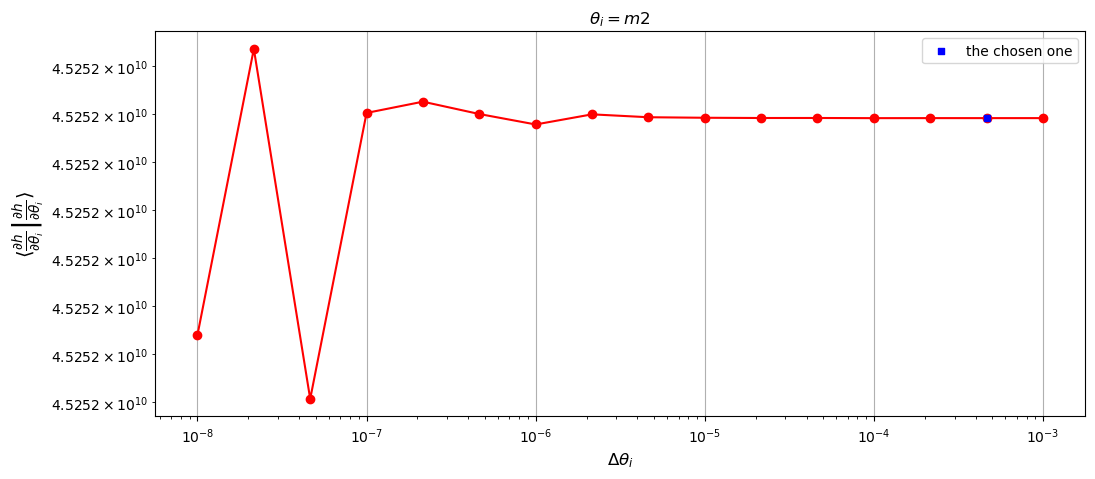

Gamma_ii for a: 2537054654706.5776
Gamma_ii for a: 2537054748264.1597
Gamma_ii for a: 2537057889832.908
Gamma_ii for a: 2537048141827.8745
Gamma_ii for a: 2537070191086.016
Gamma_ii for a: 2537044999553.043
Gamma_ii for a: 2537015436621.2695
Gamma_ii for a: 2537077999599.502
Gamma_ii for a: 2537251896103.5894
Gamma_ii for a: 2536407471084.689
Gamma_ii for a: 2536711201915.204
Gamma_ii for a: 2534631484703.098
Gamma_ii for a: 2529649057382.1636
Gamma_ii for a: 2542908492801.568
Gamma_ii for a: 2548881537727.6597
Gamma_ii for a: 2538446603733.5757
[np.float64(3.687645372858494e-08), np.float64(1.238272394620866e-06), np.float64(3.842262538490197e-06), np.float64(8.69083489257472e-06), np.float64(9.929478183312706e-06), np.float64(1.1652641661813708e-05), np.float64(2.465946188579852e-05), np.float64(6.853734323913679e-05), np.float64(0.0003329216730856238), np.float64(0.00011973409913033122), np.float64(0.000820520546934487), np.float64(0.0019696120718384123), np.float64(0.00521427941938

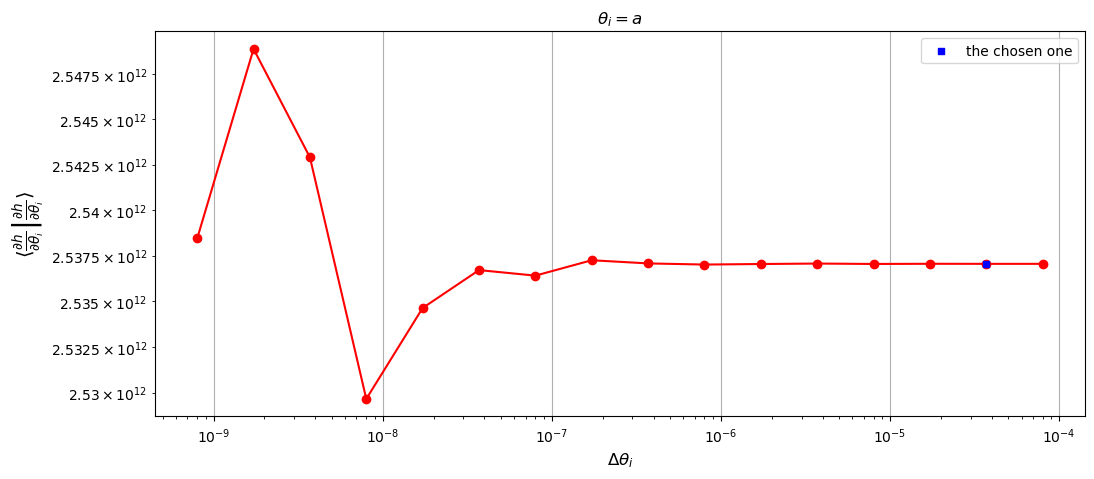

Gamma_ii for p0: 20568396310953.63
Gamma_ii for p0: 20568396748080.668
Gamma_ii for p0: 20568396459632.613
Gamma_ii for p0: 20568395032617.31
Gamma_ii for p0: 20568392677049.234
Gamma_ii for p0: 20568397501848.68
Gamma_ii for p0: 20568405676635.496
Gamma_ii for p0: 20568418387613.918
Gamma_ii for p0: 20568453193319.35
Gamma_ii for p0: 20568197252401.53
Gamma_ii for p0: 20568125519229.016
Gamma_ii for p0: 20567567969914.15
Gamma_ii for p0: 20567107937342.68
Gamma_ii for p0: 20574319910880.152
Gamma_ii for p0: 20567833328211.23
Gamma_ii for p0: 20572714682672.81
[np.float64(2.125236324524372e-08), np.float64(1.4023847471707678e-08), np.float64(6.937903042140832e-08), np.float64(1.1452368258445183e-07), np.float64(2.34573424831898e-07), np.float64(3.97443873138516e-07), np.float64(6.17985213171734e-07), np.float64(1.6921887662849954e-06), np.float64(1.2443526998479606e-05), np.float64(3.4875892044008627e-06), np.float64(2.710817903617774e-05), np.float64(2.236739228822209e-05), np.float64

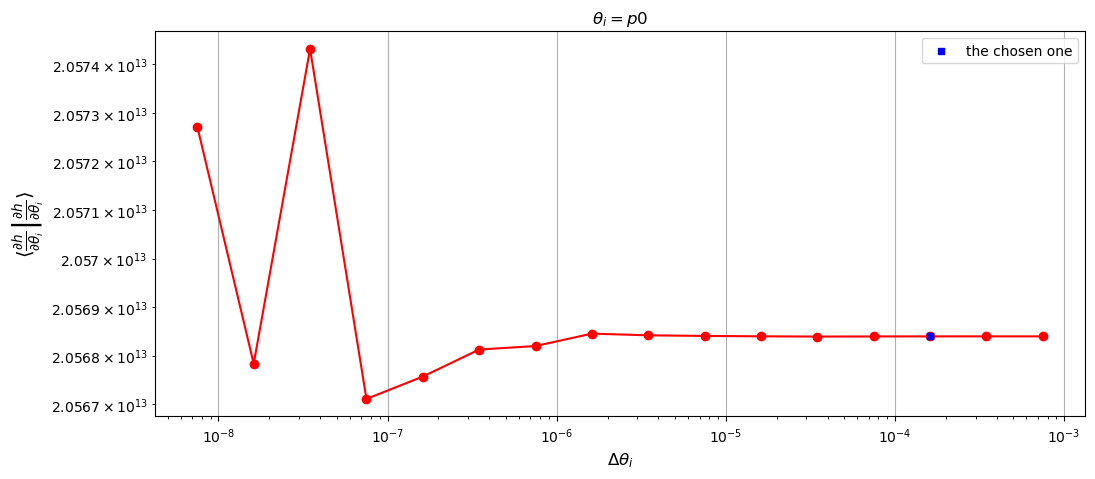

Gamma_ii for e0: 335344240026849.1
Gamma_ii for e0: 335344249173073.94
Gamma_ii for e0: 335344279078445.4
Gamma_ii for e0: 335344416456497.44
Gamma_ii for e0: 335344051380829.7
Gamma_ii for e0: 335343632618102.3
Gamma_ii for e0: 335346296203575.3
Gamma_ii for e0: 335342454007191.56
Gamma_ii for e0: 335343205340805.9
Gamma_ii for e0: 335332038648590.9
Gamma_ii for e0: 335301740639180.6
Gamma_ii for e0: 335280048192299.7
Gamma_ii for e0: 335518547764108.25
Gamma_ii for e0: 335472472096064.0
Gamma_ii for e0: 335410947950689.6
Gamma_ii for e0: 334449023511333.56
[np.float64(2.727413645844142e-08), np.float64(8.917811724619995e-08), np.float64(4.0966255980684075e-07), np.float64(1.0886600380914642e-06), np.float64(1.2487570558761658e-06), np.float64(7.942790790159925e-06), np.float64(1.1457530467250659e-05), np.float64(2.240491539254321e-06), np.float64(3.3300403564188106e-05), np.float64(9.036042983998044e-05), np.float64(6.469948628883461e-05), np.float64(0.0007108387104019164), np.float6

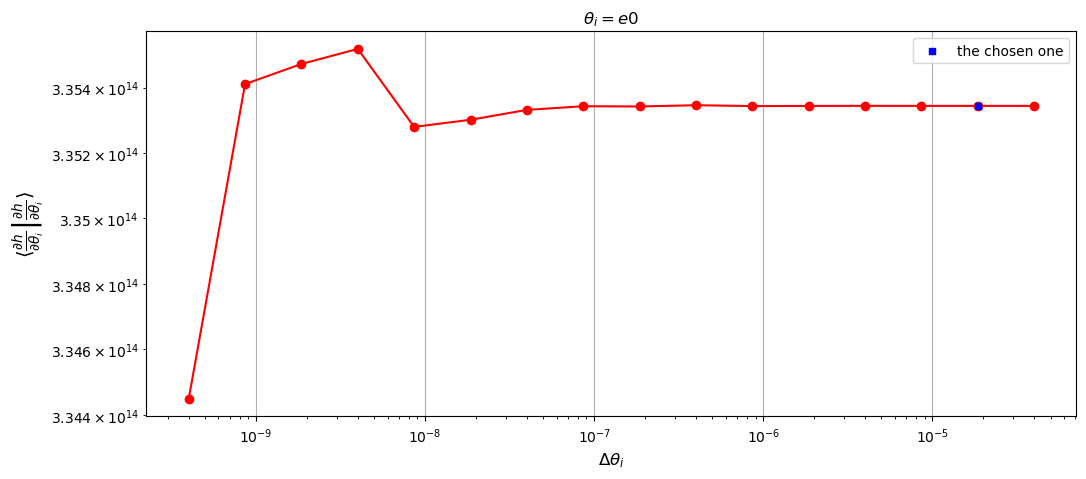

Gamma_ii for qS: 16136.006056938762
Gamma_ii for qS: 16136.00607905867
Gamma_ii for qS: 16136.006079107132
Gamma_ii for qS: 16136.006079107236
Gamma_ii for qS: 16136.00607910757
Gamma_ii for qS: 16136.006079107123
Gamma_ii for qS: 16136.00607910812
Gamma_ii for qS: 16136.006079111368
Gamma_ii for qS: 16136.006079113135
Gamma_ii for qS: 16136.006079105084
Gamma_ii for qS: 16136.006079099643
Gamma_ii for qS: 16136.006079093693
Gamma_ii for qS: 16136.006079013758
Gamma_ii for qS: 16136.00607873646
Gamma_ii for qS: 16136.006078805927
Gamma_ii for qS: 16136.006080845515
[np.float64(1.370841572873352e-09), np.float64(3.0033154085146623e-12), np.float64(6.425530301228686e-15), np.float64(2.0742062726772872e-14), np.float64(2.773123603688189e-14), np.float64(6.177527377321275e-14), np.float64(2.0133328277178058e-13), np.float64(1.0945947232439952e-13), np.float64(4.989367914603852e-13), np.float64(3.3717124791200073e-13), np.float64(3.6873525640941527e-13), np.float64(4.953858405072463e-12), n

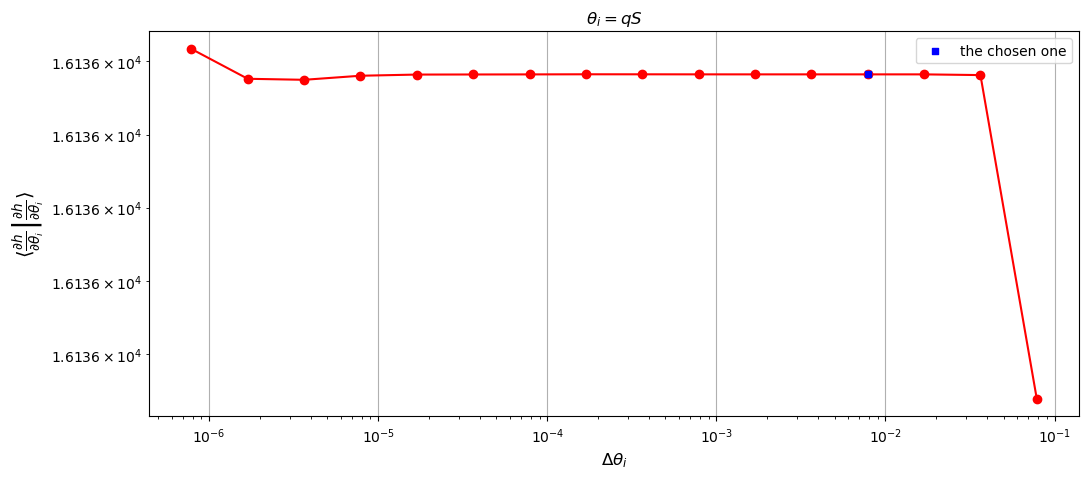

Gamma_ii for phiS: 310543.9143624892
Gamma_ii for phiS: 310543.91435780737
Gamma_ii for phiS: 310543.91435779707
Gamma_ii for phiS: 310543.91435779695
Gamma_ii for phiS: 310543.914357797
Gamma_ii for phiS: 310543.91435779695
Gamma_ii for phiS: 310543.914357797
Gamma_ii for phiS: 310543.914357797
Gamma_ii for phiS: 310543.914357797
Gamma_ii for phiS: 310543.9143577968
Gamma_ii for phiS: 310543.914357797
Gamma_ii for phiS: 310543.9143577966
Gamma_ii for phiS: 310543.9143577964
Gamma_ii for phiS: 310543.9143577999
Gamma_ii for phiS: 310543.91435779183
Gamma_ii for phiS: 310543.9143577807
[np.float64(1.5076182703289282e-11), np.float64(3.317648649785898e-14), np.float64(3.7487555364812424e-16), np.float64(1.874377768240621e-16), np.float64(1.8743777682406212e-16), np.float64(1.874377768240621e-16), np.float64(0.0), np.float64(0.0), np.float64(7.49751107296249e-16), np.float64(7.497511072962484e-16), np.float64(1.3120644377684364e-15), np.float64(5.623133304721873e-16), np.float64(1.1246266

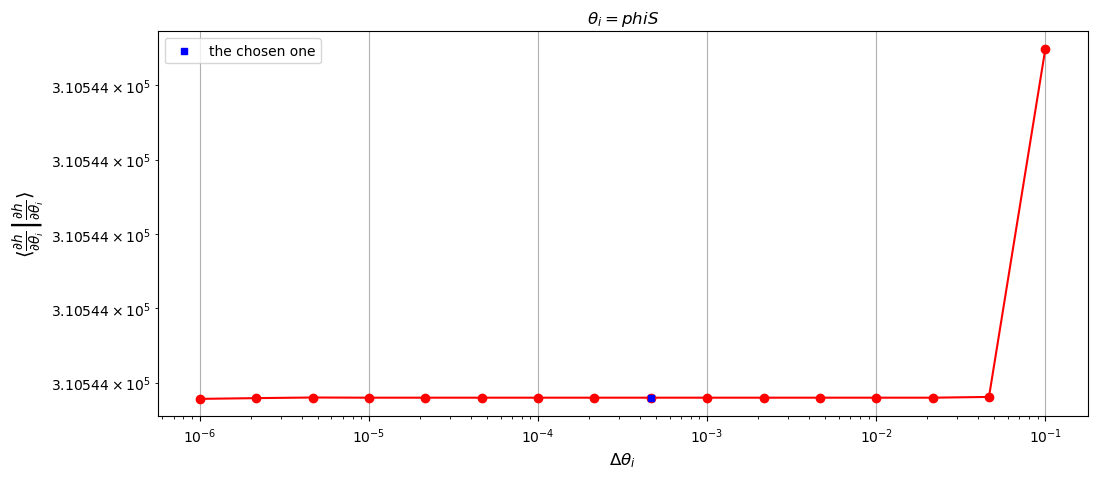

Gamma_ii for dev0p: 2626978095985.585
Gamma_ii for dev0p: 2626981863101.411
Gamma_ii for dev0p: 2627117712491.3647
Gamma_ii for dev0p: 2627071460279.255
Gamma_ii for dev0p: 2626418474968.4004
Gamma_ii for dev0p: 2626512031088.119
Gamma_ii for dev0p: 2627421068697.063
Gamma_ii for dev0p: 2630413148520.222
Gamma_ii for dev0p: 2624155124473.9155
Gamma_ii for dev0p: 2631680492090.9106
Gamma_ii for dev0p: 2660050508873.378
Gamma_ii for dev0p: 2558820837007.348
Gamma_ii for dev0p: 2633986502017.968
Gamma_ii for dev0p: 2237630965330.27
Gamma_ii for dev0p: 2073945892262.6196
Gamma_ii for dev0p: 2834250165019.9805
[np.float64(1.4340090729535618e-06), np.float64(5.1710431286607154e-05), np.float64(1.760599694724205e-05), np.float64(0.00024862196069586686), np.float64(3.561990907004956e-05), np.float64(0.0003459809391703778), np.float64(0.001137494246803936), np.float64(0.0023847767183966437), np.float64(0.0028595293538145644), np.float64(0.010665217328705144), np.float64(0.03956106281533266), np

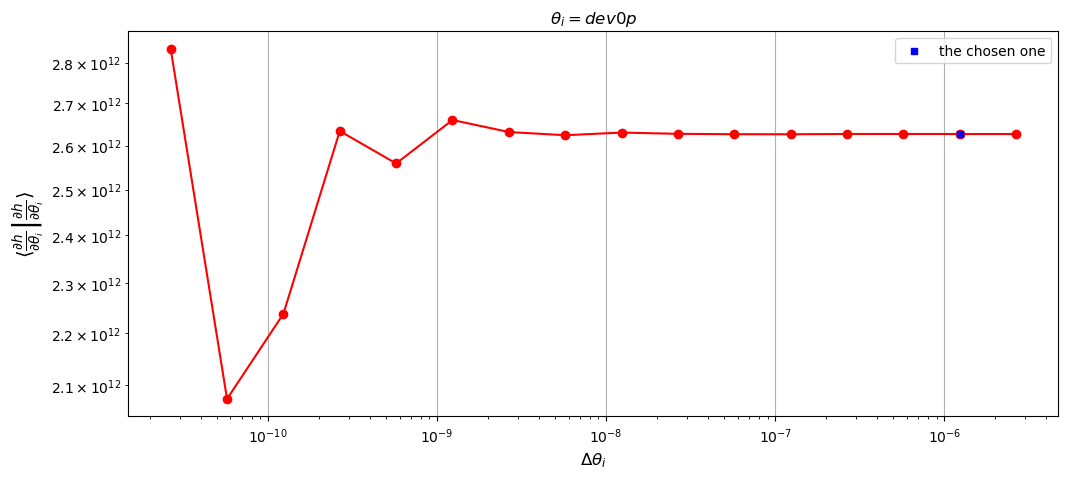

Gamma_ii for dev0e: 258574665912.12067
Gamma_ii for dev0e: 258534944466.93463
Gamma_ii for dev0e: 258442320423.38742
Gamma_ii for dev0e: 258964582906.3137
Gamma_ii for dev0e: 258491570568.83426
Gamma_ii for dev0e: 259222689710.6661
Gamma_ii for dev0e: 257971675091.44125
Gamma_ii for dev0e: 260454230197.4246
Gamma_ii for dev0e: 257294935363.6768
Gamma_ii for dev0e: 270701523626.27695
Gamma_ii for dev0e: 297422691477.39075
Gamma_ii for dev0e: 119067090908.67435
Gamma_ii for dev0e: 505697231730.86035
Gamma_ii for dev0e: 59115672141.21913
Gamma_ii for dev0e: 575528558074.5033
Gamma_ii for dev0e: 14456769738099.893
[np.float64(0.00015364052727160577), np.float64(0.00035839348368127714), np.float64(0.0020167332423029053), np.float64(0.0018298946323028035), np.float64(0.002820428808326516), np.float64(0.004849426274343553), np.float64(0.009531636725967392), np.float64(0.012278884655394624), np.float64(0.04952535206676163), np.float64(0.08984239809807877), np.float64(1.4979420359359996), np.fl

/home/svu/e1583490/scratch/packages_for_multi_inference/StableEMRIFisher/stableemrifisher/plot.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.scatter(
/home/svu/e1583490/anaconda3/envs/few_gpu/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


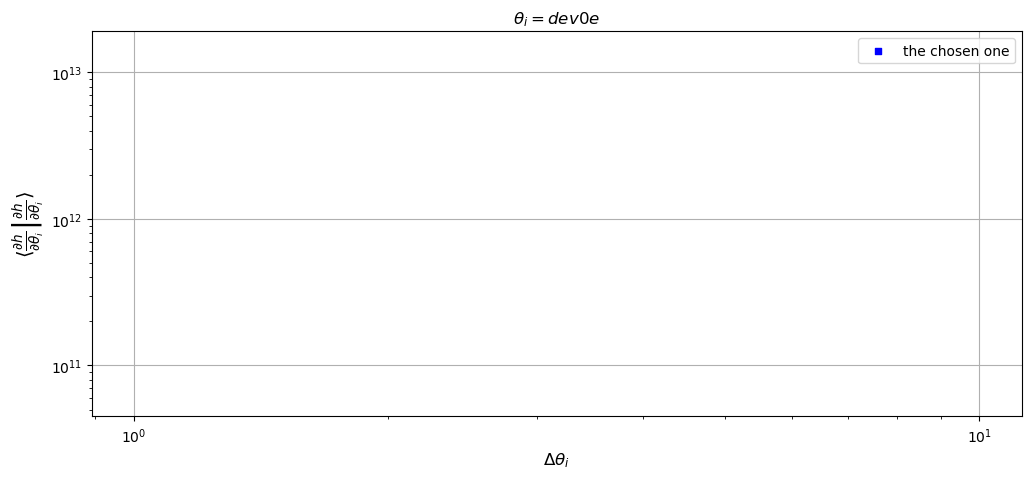

stable deltas: {'m1': 21.54516650672296, 'm2': 0.0004641493430395893, 'a': 3.713460986780533e-05, 'p0': 0.00016157812505254886, 'e0': 1.8566342291586498e-05, 'qS': 0.007854058179999998, 'phiS': 0.00046415609933629556, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 1.2334540714068603e-06, 'dev0e': -2.795983460473735e-07}
Time taken to compute stable deltas is 154.725989818573 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 10.070435285568237 seconds


In [11]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [12]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher, m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(1e6), 10, 0.8, 7.5, 0.4, np.pi/4, 1.0,  0.9,0.4,0,0])

In [13]:
pd.DataFrame(fisher_)

,0,1,2,3,4,5,6,7,8,9,10
0,5.373923e+14,-4.796178e+12,2.550035e+13,1.050345e+14,4.228305e+14,-2.390457e+09,1.102656e+10,-2.891309e+09,-2.544485e+09,-3.635773e+13,-1.160723e+13
1,-4.796178e+12,4.525202e+10,-2.622922e+11,-9.435203e+11,-3.693248e+12,1.928447e+07,-8.894937e+07,2.332423e+07,1.942337e+07,3.446892e+11,1.078589e+11
2,2.550035e+13,-2.622922e+11,2.537055e+12,5.212040e+12,1.896698e+13,-1.081676e+08,4.991920e+08,-1.311058e+08,-4.627854e+07,-2.025459e+12,-5.975997e+11
3,1.050345e+14,-9.435203e+11,5.212040e+12,2.056840e+13,8.244999e+13,-4.661208e+08,2.150136e+09,-5.638299e+08,-4.843293e+08,-7.158828e+12,-2.276994e+12
4,4.228305e+14,-3.693248e+12,1.896698e+13,8.244999e+13,3.353442e+14,-1.950574e+09,8.997643e+09,-2.359292e+09,-2.111085e+09,-2.794400e+13,-8.991002e+12
5,-2.390457e+09,1.928447e+07,-1.081676e+08,-4.661208e+08,-1.950574e+09,1.613601e+04,-6.709598e+04,1.759775e+04,1.504127e+04,1.454671e+08,4.739013e+07
6,1.102656e+10,-8.894937e+07,4.991920e+08,2.150136e+09,8.997643e+09,-6.709598e+04,3.105439e+05,-8.119419e+04,-6.937521e+04,-6.709741e+08,-2.185869e+08
7,-2.891309e+09,2.332423e+07,-1.311058e+08,-5.638299e+08,-2.359292e+09,1.759775e+04,-8.119419e+04,2.129879e+04,1.818234e+04,1.759456e+08,5.731419e+07
8,-2.544485e+09,1.942337e+07,-4.627854e+07,-4.843293e+08,-2.111085e+09,1.504127e+04,-6.937521e+04,1.818234e+04,2.090211e+04,1.450916e+08,4.915834e+07
9,-3.635773e+13,3.446892e+11,-2.025459e+12,-7.158828e+12,-2.794400e+13,1.454671e+08,-6.709741e+08,1.759456e+08,1.450916e+08,2.626982e+12,8.201220e+11


In [ ]:
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):
    """
    Plots 2D 90% and 99% confidence ellipses onto ax.
    mean: (D,) best-fit vector
    cov:  (D,D) covariance
    i,j: indices of parameters
    """
    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D-1 and j == 0:
                    # ellipse handles
                    for item in ax.get_lines():
                        if "10%" in item.get_label() or "90%" in item.get_label():
                            legend_handles.append(item)
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


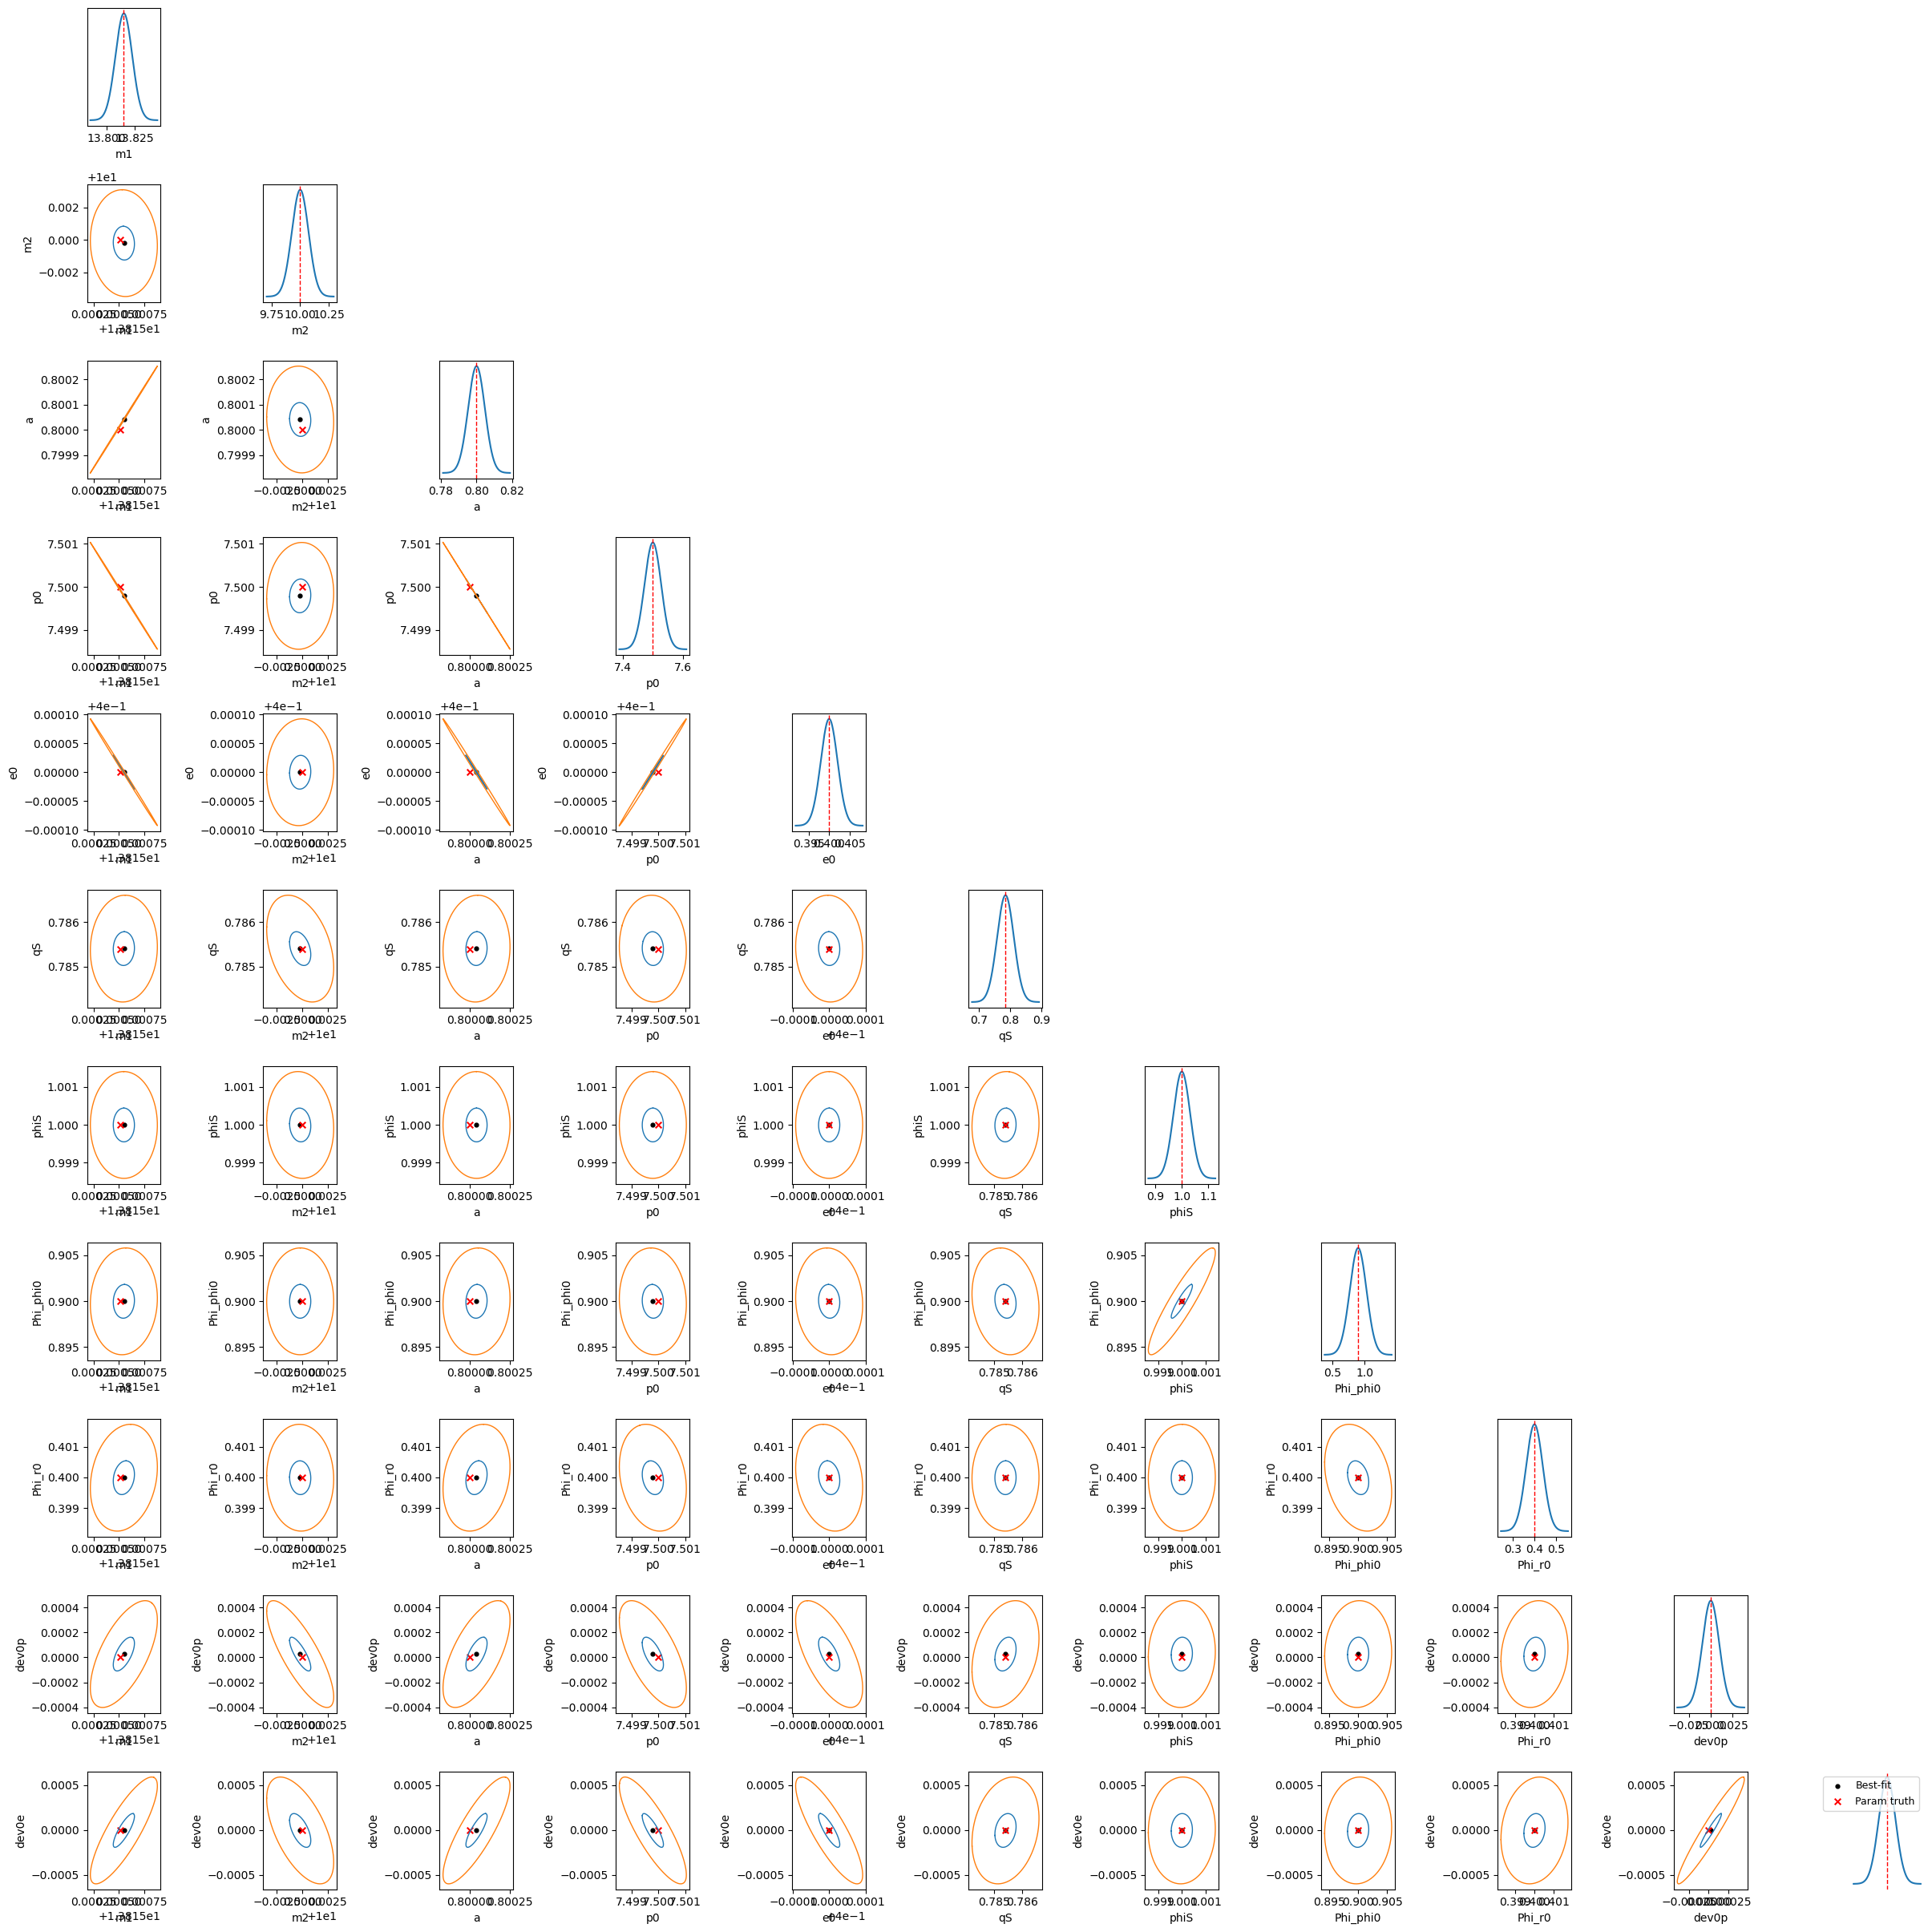

In [30]:
labels = param_names
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.0001, 0.0010])
